# Week 9 Overview

This week will be a mix of data vizualization problems and . 

The first 5 problems are data cleaning and the final 4 problems are linear algebra. 

### Data Visualization

Data visualization is a key part of exploratory data analysis (EDA), a crucial initial step for understanding a dataset and preparing for statistical modeling.

Helps visually answer questions such as:
- what patterns are evident in the data?
- what variables are important?
- does the data have anomalies or outliers?

Data visualization is also used throughout the data analysis process to show results and convey information to stakeholders.

Typically, EDA uses `histograms` & `box plots` to visualize `distribution` of a single continuous variable. `Bar charts` & `scatterplots` are used for `bivariate analysis` - correlation between two variables.


#### Histograms

![histograms](https://raw.githubusercontent.com/brendenwest/cis276/main/images/histograms.png)

Display the distribution of a continuous variable.
- Useful for visualizing the shape, for identifying
patterns or trends, for detecting
outliers, skewness, or multimodality
- Divides data into equal-width intervals (`bins`)
- Height of each `bar` represents frequency or
`count` of observations
- Can also compare the distribution of two
or more variables


#### Box & Whisker Plots

A box plot can show how tightly data is grouped, how the data is skewed, and also the symmetry of data.

![image](https://cdn1.byjus.com/wp-content/uploads/2020/10/Box-Plot-and-Whisker-Plot-2.png)

Display `median`, `quartiles`, and outliers.
- Useful for visualizing the distribution and spread.
- Box represents `interquartile range` (IQR)
- Line inside the box represents the median
- Whiskers extend from box to minimum and maximum values within 1.5 times the IQR from the box
- Values outside of this range are considered outliers and plotted as individual points


#### Scatterplots

Scatter (aka X-Y) plots show the relationship between two continuous variables. Also useful for identifying outlier data points.

![scatterplots](https://www.mathsisfun.com/data/images/correlation-examples.svg)



#### Bar Charts

Useful for visualizing distribution of `categorical` variables through relative size of bars.

-  One axis represents categories being compared
- Other axis represents frequency, count, or percentage of each category
- usually has space between bars to avoid confusion with histograms

![bar_chart](https://www.mathsisfun.com/data/images/bar-chart-movies.svg)


### Plotting with matplotlib

matplotlib is python package designed for creating (mostly two-dimensional) publication-quality plots.

It allows interactive plotting from the iPython shell or within Jupyter notebooks

matplotlib can export visualizations to  common vector and raster graphics formats (PDF, SVG, JPG, PNG, BMP, GIF, etc.).

- plots & plot types
- title & labels
- legends
- subplots
- annotations
- saving plots

### Plotting with pandas

The pandas `plot()` method is a wrapper for matplotlib's pyplot.plot() and produces the same plots, but with simpler syntax for visualizing dataframes.
`.plot()` has several optional parameters. Most notably, the `kind` parameter  determines which kind of plot you’ll create (default is a `line` plot):

- "area" for area plots.
- "bar" for vertical bar charts.
- "barh" for horizontal bar charts.
- "box" for box plots.
- "hexbin" for hexbin plots.
- "hist" for histograms.
- "kde" for kernel density estimate charts.
- "density" an alias for "kde".
- "line" for line graphs.
- "pie" for pie charts.
- "scatter" for scatter plots.

### Plotting with seaborn

Seaborn is a library for making statistical graphics in Python. It builds on top of matplotlib and integrates closely with pandas data structures.

Seaborn not only makes it easier than pandas to prepare a wider variety of plots, but supports enhancements for presentation-quality plots.

Seaborn supports several key types of plots:

- **relational** - show the relationship between two numeric variables. Includes scatter plots and line plots
- **categorical** - compare data in different categories
- **distribution** - examine how numeric data is distributed across a range of values. Types of distribution plots are histogram, kernel density estimate (KDE) plot, and empirical cumulative distribution function (ECDF) plot
- **predictive** - plots that are designed for predictive analysis, such as for linear regression models.

#### Seaborn styles

`set_style(style)`
Sets the background style with one of these values: `darkgrid`, `whitegrid`, `dark`, `white`, and `ticks` (the default). This style stays in effect until it is changed by another set_style() call.
#### General vs. specific methods

You can create Seaborn plots using the general `relplot()` command, which expects a `kind` parameter.

Alternatively, you can use a specific method - e.g. `lineplot()`, which does not require a `kind` parameter.

The two approaches mostly produce the same result, but the the general methods let you create plots with subplots, while the specific methods don’t.

So the general methods return a `FacetGrid` object that contains an `Axes` object for each subplot. The specific methods return an `Axes` object.

#### Basic Seaborn plot parameters

- data - the DataFrame of data to plot
- kind - the type of plot (general plots only)
- x, y - data columns for the x- and y-axis
- hue -  the column that determines categories to plot, with different color for each category
- palette -  color pallette for the plot
- height - The height of the plot in inches with a default of 5. (general plots only)
- aspect - the ratio of width to height (general plots only)
- legend - options for how the legend will be drawn: `auto` (the default), `brief`, `full`, and `False`. (general plots only)

#### Creating subplots

- By default, x and y labels are shared by subplots
- subplots get their title from the category label

#### Modifying plot features

The `Axes` object that provides methods for enhancing a plot.

#### Saving plots

Seaborn plots can be saved to PNG, SVG, or PDF files. The approach is slightly different for plots created with general or specific methods.

- **General method** - assign the plot's FacetGrid object to a variable and then use the `savefig()` method of the FacetGrid object
- **Specific method** - call the `get_figure()` method on the Axes object  returned by the lineplot() method, then chain go the `savefig()` method

# Data Visualization Problems

For the problems this week we are going to go a step deeper and start to ask questions about our data. 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt 

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::disability-and-health-insurance-seattle-neighborhoods/about
dis_health_df = pd.read_csv('seattle_data/disability_health_insurance_Neighborhoods.csv')
dis_health_df.columns = [i.replace(" ", "_") for i in dis_health_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::poverty-and-employment-status-seattle-neighborhoods/about
income_df = pd.read_csv('seattle_data/incomes_Neighborhoods.csv')
income_df.columns = [i.replace(" ", "_") for i in income_df.columns]

# Source: https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::incomes-occupations-and-earnings-seattle-neighborhoods/about
poverty_df = pd.read_csv('seattle_data/poverty_Neighborhoods.csv')
poverty_df.columns = [i.replace(" ", "_") for i in poverty_df.columns]

## Problem 1: Asking Questions (10 pts)

Take 5 minutes to look through the above data sources as pose 5 analytical questions you might want to ask with that data. By analytical I mean question will drive informative analysis. For example:

**Good Question**: Is there relationship between health insurance coverage and disability?

**Bad Question**: How many neighboorhoods are there?

The second question is the type of question that is is good to ask when processing the data to make sure you processed it correctly but it doesn't give you insights into the data.

At least two of the questions must involve data from at least two of the datasets.

In class you will share your questions with your group and as a group you will pick two questions to focus on for analysis in class. On your own this week you will answer the rest of your questions.

**Grading**
You will receive 2 points per question. One point for forming a question the other for it being a analytical question. 

In [2]:

dis_health_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 37 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   OBJECTID                                                         92 non-null     int64  
 1   NEIGH_NO                                                         92 non-null     float64
 2   Neighborhood_Name                                                92 non-null     object 
 3   Neighborhood_Type                                                92 non-null     object 
 4   Neighborhood_Subtype                                             85 non-null     object 
 5   ACS_Vinatage                                                     92 non-null     object 
 6   Population_18_years_and_Over                                     92 non-null     int64  
 7   Population_18_to_64_years                     

In [3]:
dis_health_df.head(20) 

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Population_18_years_and_Over,Population_18_to_64_years,Population_18_to_64_years_Below_Poverty_with_a_Disability,Population_18_to_64_years_Below_Poverty_without_a_Disability,...,Population_65_years_and_Over_with_Health_Insurance,Population_65_years_and_Over_without_Health_Insurance,Population_without_Health_Insurance,Population_under_19_years,Population_19_to_34_years,Population_35_to_64_years,Population_65_years_and_Over.1,Households,Households_with_1_or_more_persons_with_a_disability,Neighborhood_Type_(outside_comp_plan_areas_id)
0,1,1.4,Alki/Admiral,CRA,Southwest,5Y23,10131,7910,105,323,...,2221,0,447,1862,2231,5606,2221,5595,865,CRA
1,2,2.1,North Delridge,CRA,Delridge Neighborhoods,5Y23,5213,4629,28,408,...,584,0,520,558,1784,2817,584,3079,452,CRA
2,3,2.2,High Point,CRA,Delridge Neighborhoods,5Y23,6828,6084,128,584,...,744,0,279,2407,2595,3448,744,3709,756,CRA
3,4,2.3,Riverview,CRA,Delridge Neighborhoods,5Y23,3940,3497,29,147,...,437,6,78,1115,1088,2368,443,1878,329,CRA
4,5,2.4,Roxhill/Westwood,CRA,Delridge Neighborhoods,5Y23,11602,10014,397,454,...,1540,48,1043,2559,3605,6212,1588,5825,1171,CRA
5,6,2.5,Highland Park,CRA,Delridge Neighborhoods,5Y23,6641,5365,103,327,...,1215,61,500,1613,1781,3461,1276,3253,834,CRA
6,7,3.1,South Park,CRA,Greater Duwamish,5Y23,2933,2647,178,310,...,279,7,484,1028,1024,1578,286,1482,398,CRA
7,8,3.2,Georgetown,CRA,Greater Duwamish,5Y23,1066,912,13,94,...,154,0,145,120,302,605,154,702,96,CRA
8,9,3.3,Duwamish/SODO,CRA,Greater Duwamish,5Y23,2926,2417,42,253,...,494,15,258,244,1074,1343,509,1628,256,CRA
9,10,3.4,South Beacon Hill/NewHolly,CRA,Greater Duwamish,5Y23,12499,9903,259,1385,...,2560,36,928,3227,3963,5807,2596,4920,1433,CRA


In [4]:
income_df.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 69 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   OBJECTID                                                                     92 non-null     int64  
 1   NEIGH_NO                                                                     92 non-null     float64
 2   Neighborhood_Name                                                            92 non-null     object 
 3   Neighborhood_Type                                                            92 non-null     object 
 4   Neighborhood_Subtype                                                         85 non-null     object 
 5   ACS_Vinatage                                                                 92 non-null     object 
 6   Aggregate_income_in_the_past_12_months_(in_2

In [5]:
income_df.head(20) 

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars),Total_Population,Total_Households,"Household_Income_Less_than_$10,000",...,"Family_Household_Income_$100,000_or_more","Nonfamily_Household_Income_$100,000_or_more","Earnings_$50,000_or_More_Male_Workers","Earnings_$50,000_or_More_Female_Workers",Population_16_years_and_over_with_earnings,Males_16_years_and_over_with_earnings,Females_16_years_and_over_with_earnings,"Earnings_$50,000_or_More_All_Workers",Aggregate_Household_Income,Neighborhood_Type_(outside_comp_plan_areas_id)
0,1,1.0,Council District 1,CD,NaN,5Y23,7965084000,108594,48209,NaN,...,18306,9460,25368,19332,69022,36599,32423,44700,7797458400,CD
1,2,2.0,Council District 2,CD,NaN,5Y23,6355394800,108053,43824,NaN,...,14263,6486,20961,14994,66298,35636,30662,35955,6177651600,CD
2,3,3.0,Council District 3,CD,NaN,5Y23,10763937200,108012,60156,NaN,...,14102,18831,30371,22452,79057,43795,35262,52823,10593211500,CD
3,4,4.0,Council District 4,CD,NaN,5Y23,7692298500,104299,42569,NaN,...,15438,7902,21817,15841,70502,35778,34724,37658,7471995100,CD
4,5,5.0,Council District 5,CD,NaN,5Y23,7324865100,106208,47887,NaN,...,16110,8266,23739,18286,68025,36815,31210,42025,7154789000,CD
5,6,6.0,Council District 6,CD,NaN,5Y23,10191916300,105404,50023,NaN,...,19812,13304,29435,23508,71896,37157,34739,52943,10087849700,CD
6,7,7.0,Council District 7,CD,NaN,5Y23,10919759000,101881,60719,NaN,...,14201,24414,34036,23614,78442,42844,35598,57650,10779928000,CD
7,8,1.1,Arbor Heights,CRA,Southwest,5Y23,507483100,6145,2693,NaN,...,1446,308,1252,1274,3325,1478,1847,2526,507110300,CRA
8,9,1.2,Fauntleroy/Seaview,CRA,Southwest,5Y23,1300068000,15120,6879,NaN,...,3138,1330,3745,2852,9744,5070,4674,6597,1287130400,CRA
9,10,1.3,West Seattle Junction/Genesee Hill,CRA,Southwest,5Y23,1894282400,23800,11240,NaN,...,4197,2422,6590,4246,15993,9009,6984,10836,1857993300,CRA


In [6]:
income_df.columns


Index(['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage',
       'Aggregate_income_in_the_past_12_months_(in_2022_inflation-adjusted_dollars)',
       'Total_Population', 'Total_Households',
       'Household_Income_Less_than_$10,000',
       'Household_Income_$10,000_to_$14,999',
       'Household_Income_$15,000_to_$24,999',
       'Household_Income_$25,000_to_$34,999',
       'Household_Income_$35,000_to_$49,999',
       'Household_Income_$50,000_to_$74,999',
       'Household_Income_$75,000_to_$99,999',
       'Household_Income_$100,000_to_$149,999',
       'Household_Income_$150,000_to_$199,999',
       'Household_Income_$200,000_or_more', 'Total_Family_Households',
       'Family_Household_Income_Less_than_$10,000',
       'Family_Household_Income_$10,000_to_$14,999',
       'Family_Household_Income_$15,000_to_$24,999',
       'Family_Household_Income_$25,000_to_$34,999',
       'Family_Household_Income_$35,000_to_$49,9

In [7]:
poverty_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 36 columns):
 #   Column                                                                                          Non-Null Count  Dtype  
---  ------                                                                                          --------------  -----  
 0   OBJECTID                                                                                        92 non-null     int64  
 1   NEIGH_NO                                                                                        92 non-null     float64
 2   Neighborhood_Name                                                                               92 non-null     object 
 3   Neighborhood_Type                                                                               92 non-null     object 
 4   Neighborhood_Subtype                                                                            85 non-null     object 
 5   ACS_Vinatage     

In [8]:
poverty_df.head(20) 

,OBJECTID,NEIGH_NO,Neighborhood_Name,Neighborhood_Type,Neighborhood_Subtype,ACS_Vinatage,Population_16_years_and_over,Population_16_years_and_over_not_in_labor_force,Population_16_years_and_over_in_civilian_labor_force,Population_16_years_and_over_in_civilian_labor_force_unemployed,...,Population_20_to_64_years_employed,Population_20_to_64_years_below_poverty_employed,People_with_Income_to_Poverty_below_2.00,Population_20_to_64_years_in_civilian_labor_force,Population_20_to_64_years_in_civilian_labor_force_below_poverty,Population_20_to_64_years_not_in_labor_force,Population_20_to_64_years_not_in_labor_force_below_poverty,Population_20_to_64_years_unemployed,Population_20_to_64_years_unemployed_below_poverty,Neighborhood_Type_(outside_comp_plan_areas_id)
0,1,8.2,Olympic Hills/Victory Heights,CRA,North,5Y23,14516,3751,10745,574,...,9637,392,2951,10165,594,1448,293,528,202,CRA
1,2,8.3,Cedar Park/Meadowbrook,CRA,North,5Y23,12513,3677,8836,259,...,7774,250,2807,7985,321,1404,522,211,71,CRA
2,3,9.1,Broadview/Bitter Lake,CRA,Northwest,5Y23,13260,4753,8507,356,...,7454,285,3261,7776,371,1519,490,322,86,CRA
3,4,9.2,Licton Springs,CRA,Northwest,5Y23,8798,1895,6903,267,...,6339,201,2081,6601,301,1008,411,262,100,CRA
4,5,9.3,Greenwood/Phinney Ridge,CRA,Northwest,5Y23,23396,4985,18381,565,...,16629,324,2613,17105,456,2188,430,476,132,CRA
5,6,9.4,Green Lake,CRA,Northwest,5Y23,15265,3477,11779,498,...,10702,289,2625,11200,441,1300,525,498,152,CRA
6,7,9.5,Haller Lake,CRA,Northwest,5Y23,8986,2220,6766,316,...,6080,264,1311,6364,342,1056,91,284,78,CRA
7,8,10.1,North Beach/Blue Ridge,CRA,Ballard,5Y23,10485,2784,7654,343,...,6776,278,1333,7119,444,950,246,343,166,CRA
8,9,10.2,Whittier Heights,CRA,Ballard,5Y23,12384,2446,9938,173,...,9445,307,1496,9609,376,1337,374,164,69,CRA
9,10,10.3,Sunset Hill/Loyal Heights,CRA,Ballard,5Y23,13443,3746,9638,307,...,8635,152,1138,8883,152,1285,171,248,0,CRA


In [9]:
dis_health_df.columns

Index(['OBJECTID', 'NEIGH_NO', 'Neighborhood_Name', 'Neighborhood_Type',
       'Neighborhood_Subtype', 'ACS_Vinatage', 'Population_18_years_and_Over',
       'Population_18_to_64_years',
       'Population_18_to_64_years_Below_Poverty_with_a_Disability',
       'Population_18_to_64_years_Below_Poverty_without_a_Disability',
       'Population_18_to_64_years_Above_Poverty_with_a_Disability',
       'Population_18_to_64_years_Above_Poverty_without_a_Disability',
       'Population_65_years_and_Over',
       'Population_65_years_and_Over_Below_Poverty_with_a_Disability',
       'Population_65_years_and_Over_Below_Poverty_without_a_Disability',
       'Population_65_years_and_Over_Above_Poverty_with_a_Disability',
       'Population_65_years_and_Over_Above_Poverty_without_a_Disability',
       'Population_18_years_and_Over_with_a_Disability',
       'Population_18_to_64_years_with_a_Disability',
       'Population_65_years_and_Over_with_a_Disability',
       'Population_Civilian_Noninstit


# Questions to answer 

Which neighborhoods have the highest number of males who earn more than $50,000 a year?

Which neighborhoods have the highest number of females who earn more than $50,000 a year?

Are the neighborhoods that have the highest number of people who earn more than $50,000 a year also the wealthiest? 

What is the relationship between people who are unemployed and above vs below poverty? 

How are neighborhoods distributed  regarding the number of people who are 16 or older with monetary earnings?


## Problem 2: Data Cleaning and Merging (10 pts)

Take a few minutes to prepare your data for analysis. You can decide what preparation is required but you must at least perform two of the following to receive credit. You might find that you start to create a graph and then need to prepare the data better (i.e. remove an outlier) that is expected.

1. Clean up the column names.
2. Merge dataframes together. 
3. Fill in null values.
4. Removing outliers. 
5. Change the shape of the data (We will learn aggregations next week but if you know how feel free to use them).
6. Any other preparation required to answer your questions.

For each preparation step add a comment to explain why you did that step. 

**Grading** You will receive 5 points for the first two data prep steps you perform. 2 point will be for the comment and then 3 points will be for accurately performing the prep. 

In [10]:
dis_health_df = dis_health_df.drop(columns = ["Population_65_years_and_Over.1"]) #duplicate columnm

In [11]:
# delete all white space from column names 
dis_health_df.columns = dis_health_df.columns.str.strip() 
poverty_df.columns = poverty_df.columns.str.strip() 
income_df.columns = income_df.columns.str.strip() 


In [12]:
#convert to lowercase column names 
dis_health_df.columns = dis_health_df.columns.str.lower()
poverty_df.columns = poverty_df.columns.str.lower()
income_df.columns = income_df.columns.str.lower() 

In [13]:
#if there are any duplicate make them match the original column names 
dis_health_df.columns = dis_health_df.columns.str.replace(r"\.\d+", "", regex=True)
poverty_df.columns = poverty_df.columns.str.replace(r"\.\d+", "", regex=True)
income_df.columns = income_df.columns.str.replace(r"\.\d+", "", regex=True)


In [14]:
#check each 
dis_health_df.columns.duplicated().sum() 

np.int64(0)

In [15]:
poverty_df.columns.duplicated().sum() 

np.int64(2)

In [16]:
poverty_df.columns[poverty_df.columns.duplicated()]

Index(['people_with_income_to_poverty 1_to_1', 'people_with_income_to_poverty 1_to_1'], dtype='object')

In [17]:
poverty_df = poverty_df.loc[:, ~poverty_df.columns.duplicated()]
poverty_df.columns.duplicated().sum()  #get rid of duplicated columns 

np.int64(0)

In [18]:
income_df.columns.duplicated().sum() 

np.int64(0)

In [19]:
dis_health_df.isna().sum()  #check which columns have na values 

objectid                                                           0
neigh_no                                                           0
neighborhood_name                                                  0
neighborhood_type                                                  0
neighborhood_subtype                                               7
acs_vinatage                                                       0
population_18_years_and_over                                       0
population_18_to_64_years                                          0
population_18_to_64_years_below_poverty_with_a_disability          0
population_18_to_64_years_below_poverty_without_a_disability       0
population_18_to_64_years_above_poverty_with_a_disability          0
population_18_to_64_years_above_poverty_without_a_disability       0
population_65_years_and_over                                       0
population_65_years_and_over_below_poverty_with_a_disability       0
population_65_years_and_over_below

In [20]:
dis_health_df.isna().sum().sum() #and check how many there are in total 

np.int64(7)

In [21]:
poverty_df.isna().sum()

objectid                                                                                          0
neigh_no                                                                                          0
neighborhood_name                                                                                 0
neighborhood_type                                                                                 0
neighborhood_subtype                                                                              7
acs_vinatage                                                                                      0
population_16_years_and_over                                                                      0
population_16_years_and_over_not_in_labor_force                                                   0
population_16_years_and_over_in_civilian_labor_force                                              0
population_16_years_and_over_in_civilian_labor_force_unemployed                                   0


In [22]:
poverty_df.isna().sum().sum()



np.int64(7)

In [23]:
income_df.isna().sum() 

objectid                                          0
neigh_no                                          0
neighborhood_name                                 0
neighborhood_type                                 0
neighborhood_subtype                              7
                                                 ..
males_16_years_and_over_with_earnings             0
females_16_years_and_over_with_earnings           0
earnings_$50,000_or_more_all_workers              0
aggregate_household_income                        0
neighborhood_type_(outside_comp_plan_areas_id)    0
Length: 69, dtype: int64

In [24]:
income_df.isna().sum().sum()

np.int64(283)

In [25]:
income_df.isna().sum()[income_df.isna().sum() > 0] #check which columns 

neighborhood_subtype                             7
household_income_less_than_$10,000              92
family_household_income_less_than_$10,000       92
nonfamily_household_income_less_than_$10,000    92
dtype: int64

In [26]:
dis_health_df["neigh_no"].duplicated().sum()  #check if there are duplicate keys 

np.int64(0)

In [27]:
income_df["neigh_no"].duplicated().sum() #same here 


np.int64(0)

In [28]:
poverty_df["neigh_no"].duplicated().sum() # and here 

np.int64(0)

In [29]:
merge_df = dis_health_df.merge(poverty_df, on = "neigh_no", how = "left") #there arent so merge on the neighbord number 
merge_df = merge_df.merge(income_df, on = "neigh_no", how = "left" ) #and this dataset as well with a left join 

In [30]:
merge_df.head(20) #take a look at the merged dataset 

,objectid_x,neigh_no,neighborhood_name_x,neighborhood_type_x,neighborhood_subtype_x,acs_vinatage_x,population_18_years_and_over,population_18_to_64_years,population_18_to_64_years_below_poverty_with_a_disability,population_18_to_64_years_below_poverty_without_a_disability,...,"family_household_income_$100,000_or_more","nonfamily_household_income_$100,000_or_more","earnings_$50,000_or_more_male_workers","earnings_$50,000_or_more_female_workers",population_16_years_and_over_with_earnings,males_16_years_and_over_with_earnings,females_16_years_and_over_with_earnings,"earnings_$50,000_or_more_all_workers",aggregate_household_income,neighborhood_type_(outside_comp_plan_areas_id)
0,1,1.4,Alki/Admiral,CRA,Southwest,5Y23,10131,7910,105,323,...,2582,1152,2822,2620,7404,3773,3631,5442,1135214800,CRA
1,2,2.1,North Delridge,CRA,Delridge Neighborhoods,5Y23,5213,4629,28,408,...,845,787,1471,1196,4089,2149,1940,2667,437055600,CRA
2,3,2.2,High Point,CRA,Delridge Neighborhoods,5Y23,6828,6084,128,584,...,1215,600,1737,1324,4944,2568,2376,3061,465393800,CRA
3,4,2.3,Riverview,CRA,Delridge Neighborhoods,5Y23,3940,3497,29,147,...,844,363,1403,896,3318,1836,1482,2299,347666900,CRA
4,5,2.4,Roxhill/Westwood,CRA,Delridge Neighborhoods,5Y23,11602,10014,397,454,...,2026,978,2804,2426,9388,4597,4791,5230,783226600,CRA
5,6,2.5,Highland Park,CRA,Delridge Neighborhoods,5Y23,6641,5365,103,327,...,1311,442,1678,1259,4773,2588,2185,2937,453617200,CRA
6,7,3.1,South Park,CRA,Greater Duwamish,5Y23,2933,2647,178,310,...,315,259,763,386,2497,1437,1060,1149,195050000,CRA
7,8,3.2,Georgetown,CRA,Greater Duwamish,5Y23,1066,912,13,94,...,119,213,339,249,919,530,389,588,91877800,CRA
8,9,3.3,Duwamish/SODO,CRA,Greater Duwamish,5Y23,2926,2417,42,253,...,491,408,897,799,2596,1519,1077,1696,227699300,CRA
9,10,3.4,South Beacon Hill/NewHolly,CRA,Greater Duwamish,5Y23,12499,9903,259,1385,...,1438,369,1831,1445,8796,4416,4380,3276,531905600,CRA


In [31]:
merge_df = merge_df[~merge_df["neighborhood_name"].str.contains("Council District")] #remove the council district rows 
merge_df = merge_df[~merge_df["neighborhood_name"].str.contains("Outside Villages")] #and outsid villages 

In [32]:
merge_df.columns

Index(['objectid_x', 'neigh_no', 'neighborhood_name_x', 'neighborhood_type_x',
       'neighborhood_subtype_x', 'acs_vinatage_x',
       'population_18_years_and_over', 'population_18_to_64_years',
       'population_18_to_64_years_below_poverty_with_a_disability',
       'population_18_to_64_years_below_poverty_without_a_disability',
       ...
       'family_household_income_$100,000_or_more',
       'nonfamily_household_income_$100,000_or_more',
       'earnings_$50,000_or_more_male_workers',
       'earnings_$50,000_or_more_female_workers',
       'population_16_years_and_over_with_earnings',
       'males_16_years_and_over_with_earnings',
       'females_16_years_and_over_with_earnings',
       'earnings_$50,000_or_more_all_workers', 'aggregate_household_income',
       'neighborhood_type_(outside_comp_plan_areas_id)'],
      dtype='object', length=137)

In [33]:
merge_df.columns[merge_df.columns.str.contains("64")]

Index(['population_18_to_64_years',
       'population_18_to_64_years_below_poverty_with_a_disability',
       'population_18_to_64_years_below_poverty_without_a_disability',
       'population_18_to_64_years_above_poverty_with_a_disability',
       'population_18_to_64_years_above_poverty_without_a_disability',
       'population_18_to_64_years_with_a_disability',
       'population_35_to_64_years_with_health_insurance',
       'population_35_to_64_years_without_health_insurance',
       'population_35_to_64_years',
       'population_20_to_64_years_for_whom_poverty_status_is_determined',
       'population_20_to_64_years_below_poverty',
       'population_20_to_64_years_employed',
       'population_20_to_64_years_below_poverty_employed',
       'population_20_to_64_years_in_civilian_labor_force',
       'population_20_to_64_years_in_civilian_labor_force_below_poverty',
       'population_20_to_64_years_not_in_labor_force',
       'population_20_to_64_years_not_in_labor_force_below_p

In [34]:
merge_df.columns[merge_df.columns.str.contains("18")] #checking for age range 

Index(['population_18_years_and_over', 'population_18_to_64_years',
       'population_18_to_64_years_below_poverty_with_a_disability',
       'population_18_to_64_years_below_poverty_without_a_disability',
       'population_18_to_64_years_above_poverty_with_a_disability',
       'population_18_to_64_years_above_poverty_without_a_disability',
       'population_18_years_and_over_with_a_disability',
       'population_18_to_64_years_with_a_disability',
       'married-couple_family_with_related_children_of_the_householder_under_18_years_below_poverty',
       'married-couple_family_without_related_children_of_the_householder_under_18_years_below_poverty',
       'single_parents_with_related_children_of_the_householder_under_18_years_below_poverty'],
      dtype='object')

In [35]:
merge_df.columns[merge_df.columns.str.contains("population")] #checking for population 

Index(['population_18_years_and_over', 'population_18_to_64_years',
       'population_18_to_64_years_below_poverty_with_a_disability',
       'population_18_to_64_years_below_poverty_without_a_disability',
       'population_18_to_64_years_above_poverty_with_a_disability',
       'population_18_to_64_years_above_poverty_without_a_disability',
       'population_65_years_and_over',
       'population_65_years_and_over_below_poverty_with_a_disability',
       'population_65_years_and_over_below_poverty_without_a_disability',
       'population_65_years_and_over_above_poverty_with_a_disability',
       'population_65_years_and_over_above_poverty_without_a_disability',
       'population_18_years_and_over_with_a_disability',
       'population_18_to_64_years_with_a_disability',
       'population_65_years_and_over_with_a_disability',
       'population_civilian_noninstitutionalized',
       'population_under_19_years_with_health_insurance',
       'population_under_19_years_without_health

## Problem 3: Question 1 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

In [36]:
top_earners = merge_df.sort_values("earnings_$50,000_or_more_male_workers", ascending=False).head(10)


# Question 1: 
# What are the top  neighborhoods regarding males that earn 50,000$ or more? 

I compared the top 10 neighborhoods in which males make 50,000$ or more.  First Hill, Queen Anne, Downtown, and eastlake make up 4 neighborhoods with a population of males over 10,000, whereas Fremont and Ravenna make up the lower echelon of the top 10, with ~6000.  I interpreted this high concentration of males in these neighborhoods to be true because these are all relatviely areas that make up the urban core of seattle, along with the high population density in these areas




C:\Users\yahar\AppData\Local\Temp\ipykernel_97816\2836536378.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_earners, x = "earnings_$50,000_or_more_male_workers", y = "neighborhood_name", palette="Greens_r", edgecolor = "black")# choose data , x = earnings ,  y=  neighborhood, and reverse greens so highest values are dark green, edgecolor to make the bars visible


Text(0, 0.5, 'neighborhood')

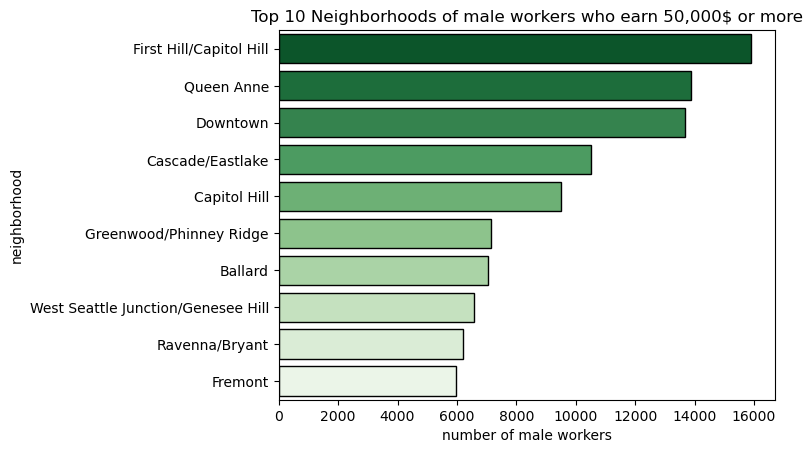

In [37]:
sns.barplot(data = top_earners, x = "earnings_$50,000_or_more_male_workers", y = "neighborhood_name", palette="Greens_r", edgecolor = "black")# choose data , x = earnings ,  y=  neighborhood, and reverse greens so highest values are dark green, edgecolor to make the bars visible 
plt.title("Top 10 Neighborhoods of male workers who earn 50,000$ or more" )  # add title 
plt.xlabel("number of male workers") # x axis label 
plt.ylabel("neighborhood") #y axis label 


## Problem 4: Question 2 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

In [38]:
top_f_earners = merge_df.sort_values("earnings_$50,000_or_more_female_workers", ascending=False).head(10)

# Question 2: 
## What are the top 10 neighborhoods regarding females that earn 50,000$ or more? 

Similarly, regarding the top neighborhoods consisting of females that earn 50,000$ or more, the list  included first hill, queene anne, downtown, and eastlake, with Queen Anne being the  top neighborhood regarding population size of women who earn 50,000$ or more, rather than first hill being the top neighborhood for males.  The same neighborhoods appearing in both male and female lists can suggest that areas with large labor force populations tend to contain high earning workers across both genders. This could be attributed to higher population density in these urban areas.

C:\Users\yahar\AppData\Local\Temp\ipykernel_97816\3746262681.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_earners, x = "earnings_$50,000_or_more_female_workers", y = "neighborhood_name", palette="Greens_r", edgecolor = "black")


Text(0, 0.5, 'neighborhood')

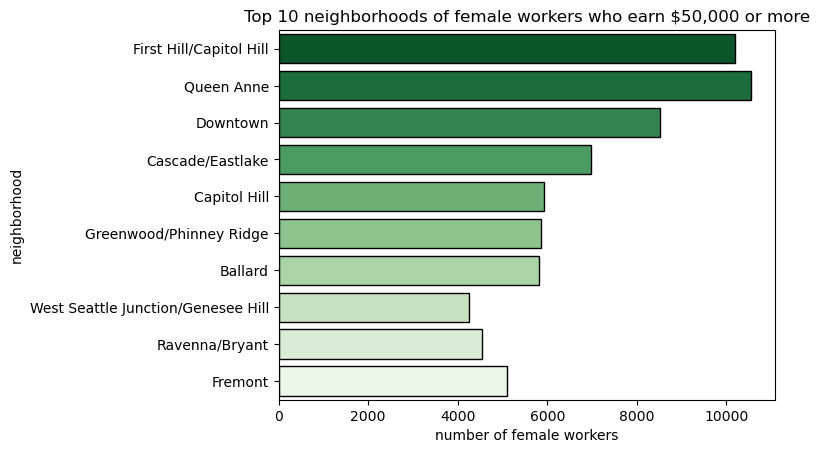

In [39]:
sns.barplot(data = top_earners, x = "earnings_$50,000_or_more_female_workers", y = "neighborhood_name", palette="Greens_r", edgecolor = "black")
plt.title("Top 10 neighborhoods of female workers who earn $50,000 or more")
plt.xlabel("number of female workers")
plt.ylabel("neighborhood")

In [40]:
merge_df.columns[merge_df.columns.str.contains("disability", regex=False)] #just looking for columns 

Index(['population_18_to_64_years_below_poverty_with_a_disability',
       'population_18_to_64_years_below_poverty_without_a_disability',
       'population_18_to_64_years_above_poverty_with_a_disability',
       'population_18_to_64_years_above_poverty_without_a_disability',
       'population_65_years_and_over_below_poverty_with_a_disability',
       'population_65_years_and_over_below_poverty_without_a_disability',
       'population_65_years_and_over_above_poverty_with_a_disability',
       'population_65_years_and_over_above_poverty_without_a_disability',
       'population_18_years_and_over_with_a_disability',
       'population_18_to_64_years_with_a_disability',
       'population_65_years_and_over_with_a_disability',
       'households_with_1_or_more_persons_with_a_disability'],
      dtype='object')

In [41]:
merge_df.select_dtypes(include="number").columns # looking  for numeric columns 

Index(['objectid_x', 'neigh_no', 'population_18_years_and_over',
       'population_18_to_64_years',
       'population_18_to_64_years_below_poverty_with_a_disability',
       'population_18_to_64_years_below_poverty_without_a_disability',
       'population_18_to_64_years_above_poverty_with_a_disability',
       'population_18_to_64_years_above_poverty_without_a_disability',
       'population_65_years_and_over',
       'population_65_years_and_over_below_poverty_with_a_disability',
       ...
       'household_income_$100,000_or_more',
       'family_household_income_$100,000_or_more',
       'nonfamily_household_income_$100,000_or_more',
       'earnings_$50,000_or_more_male_workers',
       'earnings_$50,000_or_more_female_workers',
       'population_16_years_and_over_with_earnings',
       'males_16_years_and_over_with_earnings',
       'females_16_years_and_over_with_earnings',
       'earnings_$50,000_or_more_all_workers', 'aggregate_household_income'],
      dtype='object', le

## Problem 5: Question 3 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

# Question 3: 
## What is the relationship between people who are unemployed regarding levels of poverty?

From the visualization we can observe that generally speaking, neighborhoods with fewer unemployed people tend to also have fewer people living below the poverty line. However, the scatterplot also shows that htis relationship is not the entire story. Some nieghborhoods with relatively moderate unemployment still have a large number of people below the poverty threshold. For example, several points on the plot show neighborhoods with around 150 unemployed individuals, yet nearly 100 of thsoe individuals fall below the poverty line.


 There is also an extreme outlier, where around 2,000 individuals are unemployed and roughly 800 fall below the poverty line which could be indicative of a neighborhood experiencing economic hardship. Conversely another point on the plot shows a neighborhood iwth around 1,000 unemployed individuals, but fewer than 200 below the poverty line. This could indicate despite higher unemployment, a smaller portion fall under the poverty threhold 

Text(0.5, 1.0, 'Relationship between Unemployment and Poverty (20-64)')

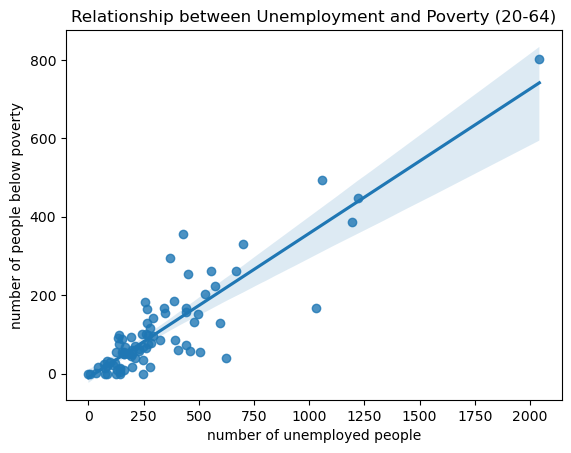

In [42]:
sns.regplot(data = merge_df, x = "population_20_to_64_years_unemployed", y = "population_20_to_64_years_unemployed_below_poverty",)
plt.ylabel("number of people below poverty" )# y label 
plt.xlabel("number of unemployed people") #x label
plt.title("Relationship between Unemployment and Poverty (20-64)")#title 

## Problem 6: Question 4 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

# Question 4: 
## Are the neighborhoods that have the highest amount of people who make over $50,000 a year also the wealthiest? 

From the visualization, we can see that the neighborhoods that have the highest population of men and women who make over $50,000 a year are also the neighborhoods that have the highest aggregate household income. We can see that Queen Anne makes ~4.6 billion dollars in aggregate household income, followed by first hill(~4.2) and downtown (~4.1) making roughly similar ammounts, before dropping slightly with eastlake having a aggregate household income of ~3.1 billion.

An interesting observation I found was that Queen Anne despite being a residential neighborhood having the highest aggregate income amongst  urban centers like downtown, capitol hill, or eastlake, with these areas having major places of employment (tech companies, hospitals, corporate offices). This suggests variation in how different subsets of population choose where to live based on their own preferences (some preferring to live in in the middle of downtown vs others choosing to live in a more residential area) 

In [43]:
top_house_earners = merge_df.sort_values("aggregate_household_income", ascending=False).head(10) # sort by highest aggregate income

C:\Users\yahar\AppData\Local\Temp\ipykernel_97816\2376874762.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = top_house_earners, x = "neighborhood_name", y = "aggregate_household_income", palette = "Greens_r", edgecolor = "black")


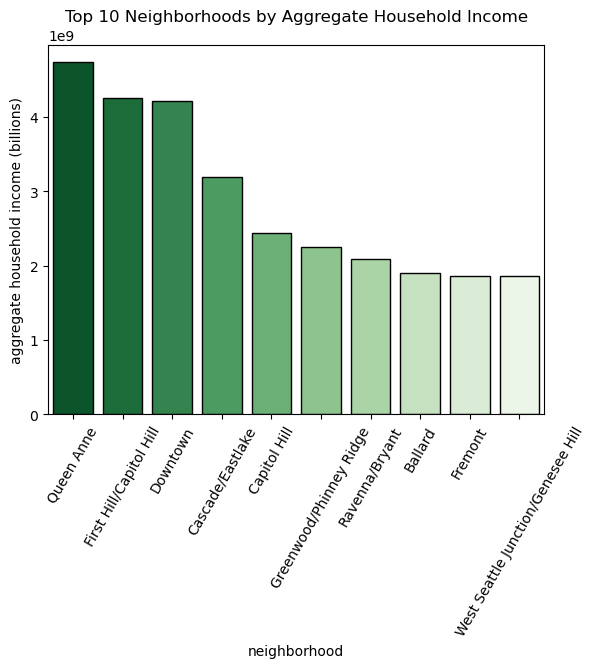

In [44]:
sns.barplot(data = top_house_earners, x = "neighborhood_name", y = "aggregate_household_income", palette = "Greens_r", edgecolor = "black")
plt.title("Top 10 Neighborhoods by Aggregate Household Income") # title 
plt.xlabel("neighborhood") # x and y labels 
plt.ylabel("aggregate household income (billions)")
plt.xticks(rotation=60) #to make the text less crowded 
plt.show() 
 


## Problem 7: Question 5 (12 pts)

You will prepare a visualization for the question you asked by completing the following steps: 

1. Add a mark down cell writing out your question and your findings.
2. Create a visual two answer the question. Perform at least 2 modifications of the graph to empathise what you found in the data (https://www.youtube.com/watch?v=IM-r9lEZciM). You must add a comment to your code explain the modifications you made. For example:
    * Add a decriptive title
    * Modify the color(s) in your graph
    * Pick a accurate scale to communicate your findings without skewing the data. (Watch https://www.youtube.com/watch?v=9pNWVMxaFuM)



**Grading** 

You will receive 3 points for the mark down cell writing out your questions and findings. 

You will receive 3 points for picking the correct visualization for your question and data. 

For each graph modification you will get 2 points for correctly coding the modification and 1 point for the comment explaining why you picked that modification.  

# Question 5: 
## How are neighborhoods distributed  regarding the number of people who are 16 or older with monetary earnings?

The histogram shows a right skewed distribution of residents  who are 16 or older with earnings across neighborhoods. Most of the neighborhoods contain around 4,000-10,000 residents with earnings, with the highest concentration of neighborhoods being around the range of ~5000. A smaller number of neighborhoods have much larger populations of residents with earnings, creating the tail on the right side of the  distribution 

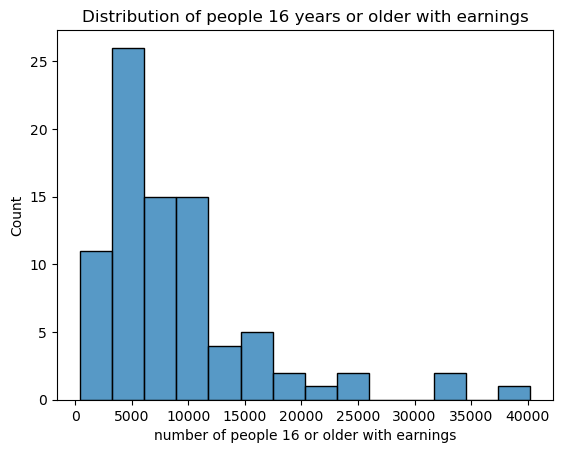

In [45]:
sns.histplot(data = merge_df, x = "population_16_years_and_over_with_earnings" )
plt.title("Distribution of people 16 years or older with earnings") # title 
plt.xlabel("number of people 16 or older with earnings") # x label 
plt.show() 

## Problem 8 (10pts)
Pick 5 columns in the datasets above and create a covariance by completing the following steps:

1. Mean center all columns. You can use panda's mean function for this. 
2. Create a covariance matrix as follows:
$$ C = X^T X \dfrac{1}{n-1}$$
3. You should save this to a dateframe called `cov_df` to be used in the next problem. 
4. Output the results of `cov_df` and visually check your results against [DataFrame.cov](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.cov.html). The numbers should match. 

In [ ]:
cols = ["population_16_years_and_over_with_earnings", "aggregate_household_income", "earnings_$50,000_or_more_female_workers", "population_20_to_64_years_unemployed", "earnings_$50,000_or_more_male_workers"]



original_df = merge_df[cols] # create the df of 5 columns 

centered_df = original_df.subtract(original_df.mean()) #center data by subtracting mean from every column

cov_df = (centered_df.T @ centered_df) / (len(centered_df) -  1) #calculate covariance matrix using fromula provided 

In [47]:
cov_df

,population_16_years_and_over_with_earnings,aggregate_household_income,"earnings_$50,000_or_more_female_workers",population_20_to_64_years_unemployed,"earnings_$50,000_or_more_male_workers"
population_16_years_and_over_with_earnings,5.219358e+07,5.911840e+12,1.359596e+07,2.011219e+06,2.025068e+07
aggregate_household_income,5.911840e+12,7.787623e+17,1.733240e+12,2.329545e+11,2.525803e+12
"earnings_$50,000_or_more_female_workers",1.359596e+07,1.733240e+12,4.055226e+06,5.392921e+05,5.778262e+06
population_20_to_64_years_unemployed,2.011219e+06,2.329545e+11,5.392921e+05,9.572799e+04,8.206831e+05
"earnings_$50,000_or_more_male_workers",2.025068e+07,2.525803e+12,5.778262e+06,8.206831e+05,8.574527e+06


## Problem 9 (10pts)

Next you will take the `cov_df` and create a correlation matrix from it. The formula for this is

$$ R = SCS $$

Where $C$ is the covariance matrix `cov_df`, and $S$ is a diagonal matrix of reciprocated standard deviations per variable (that is, the ith diagonal is $\dfrac{1}{\sigma_i}$ where $\sigma_i$ is the standard deviation of variable i). You can use panda's standard deviation function to create $S$. 

Once you have created the correlation matrix visually compare it to [np.corrcoef](https://numpy.org/doc/2.2/reference/generated/numpy.corrcoef.html)

In [54]:
std_devs = original_df.std()   #calculate std deviation of each column 

recip = 1 / std_devs  #take recipricol 

std_matrix = np.diag(recip) # create a diagonal matrix with the rceirpicols 

corr_calc = std_matrix @ cov_df @ std_matrix #calcualte correlation matrix using formula 



In [51]:
corr_calc

,0,1,2,3,4
0,1.000000,0.927282,0.934531,0.899770,0.957251
1,0.927282,1.000000,0.975324,0.853197,0.977444
2,0.934531,0.975324,1.000000,0.865560,0.979906
3,0.899770,0.853197,0.865560,1.000000,0.905839
4,0.957251,0.977444,0.979906,0.905839,1.000000


In [53]:
official_corr = np.corrcoef(original_df, rowvar=False) 
official_corr

array([[1.        , 0.92728171, 0.93453124, 0.89976967, 0.95725131],
       [0.92728171, 1.        , 0.97532371, 0.85319677, 0.97744402],
       [0.93453124, 0.97532371, 1.        , 0.86555971, 0.9799064 ],
       [0.89976967, 0.85319677, 0.86555971, 1.        , 0.90583886],
       [0.95725131, 0.97744402, 0.9799064 , 0.90583886, 1.        ]])